In [ ]:
!pip install -q lightgbm shap imbalanced-learn scikit-learn pandas numpy matplotlib seaborn
print('✅ All packages installed.')

✅ All packages installed.


In [ ]:
from google.colab import drive
import zipfile, os

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/unsw.zip'   # ← your file

extract_dir = '/content/unsw_data'
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)
    print(f'✅ Extracted: {z.namelist()}')
# Auto-detect CSV paths
all_files = []
for root, dirs, fnames in os.walk(extract_dir):
    for f in fnames:
        if f.endswith('.csv'):
            all_files.append(os.path.join(root, f))

print(f'\n📄 CSVs found:')
for f in all_files:
    print(f'   {f}')

TRAIN_PATH = [f for f in all_files if 'train' in f.lower()][0]
TEST_PATH  = [f for f in all_files if 'test'  in f.lower()][0]
print(f'\n✅ Train → {TRAIN_PATH}')
print(f'✅ Test  → {TEST_PATH}')

Mounted at /content/drive
✅ Extracted: ['Training and Testing Sets/UNSW_NB15_testing-set.csv', 'Training and Testing Sets/UNSW_NB15_training-set.csv']

📄 CSVs found:
   /content/unsw_data/Training and Testing Sets/UNSW_NB15_training-set.csv
   /content/unsw_data/Training and Testing Sets/UNSW_NB15_testing-set.csv

✅ Train → /content/unsw_data/Training and Testing Sets/UNSW_NB15_training-set.csv
✅ Test  → /content/unsw_data/Training and Testing Sets/UNSW_NB15_training-set.csv


In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, f1_score,
    precision_recall_fscore_support
)
from imblearn.over_sampling import SMOTE
import lightgbm as lgb

warnings.filterwarnings('ignore')
shap.initjs()
print('✅ All imports OK.')

✅ All imports OK.


In [ ]:
train_df = pd.read_csv(TRAIN_PATH, low_memory=False)
test_df  = pd.read_csv(TEST_PATH,  low_memory=False)

# Normalise column names
train_df.columns = train_df.columns.str.strip().str.lower()
test_df.columns  = test_df.columns.str.strip().str.lower()

print(f'Train shape : {train_df.shape}')
print(f'Test shape  : {test_df.shape}')
print(f'\nColumns: {list(train_df.columns)}')
print(f'\nAttack categories (train):')
print(train_df['attack_cat'].value_counts())

Train shape : (175341, 45)
Test shape  : (175341, 45)

Columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Attack categories (train):
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [ ]:
# ── Normalise attack_cat ──────────────────────────────────────────────────────
for df in [train_df, test_df]:
    df['attack_cat'] = (
        df['attack_cat'].astype(str)
          .str.strip().str.lower()
          .replace({'nan': 'normal', '': 'normal',
                    ' backdoors': 'backdoor', 'backdoors': 'backdoor'})
    )

# ── Drop ID / binary label columns ───────────────────────────────────────────
DROP = ['id', 'label']
for col in DROP:
    for df in [train_df, test_df]:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

# ── Encode categorical features ───────────────────────────────────────────────
CAT_COLS = ['proto', 'service', 'state']
le_dict = {}
for col in CAT_COLS:
    if col in train_df.columns:
        le = LabelEncoder()
        combined = pd.concat([train_df[col], test_df[col]]).astype(str)
        le.fit(combined)
        train_df[col] = le.transform(train_df[col].astype(str))
        test_df[col]  = le.transform(test_df[col].astype(str))
        le_dict[col]  = le

# ── Encode target ─────────────────────────────────────────────────────────────
TARGET       = 'attack_cat'
FEATURE_COLS = [c for c in train_df.columns if c != TARGET]

le_target = LabelEncoder()
y_train   = le_target.fit_transform(train_df[TARGET])
y_test    = le_target.transform(test_df[TARGET])
CLASS_NAMES = le_target.classes_
print(f'Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}')

X_train = train_df[FEATURE_COLS].copy()
X_test  = test_df[FEATURE_COLS].copy()

# ── Clean infinities and NaNs ─────────────────────────────────────────────────
for df in [X_train, X_test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
train_medians = X_train.median()
X_train.fillna(train_medians, inplace=True)
X_test.fillna(train_medians, inplace=True)

# ── Scale ─────────────────────────────────────────────────────────────────────
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)
FEATURE_ARR = np.array(FEATURE_COLS)

print(f'\nX_train: {X_train_sc.shape}  |  X_test: {X_test_sc.shape}')
print('✅ Preprocessing complete.')

Classes (10): ['analysis' 'backdoor' 'dos' 'exploits' 'fuzzers' 'generic' 'normal'
 'reconnaissance' 'shellcode' 'worms']

X_train: (175341, 42)  |  X_test: (175341, 42)
✅ Preprocessing complete.


Training Isolation Forest...
✅ Isolation Forest trained.

Anomaly threshold (ROC-based): -0.0177
Train flagged as anomaly : 52603 / 175341 (30.0%)
Test  flagged as anomaly : 52603  / 175341  (30.0%)

Augmented feature matrix: (175341, 44)  (original 42 + 2 anomaly features)


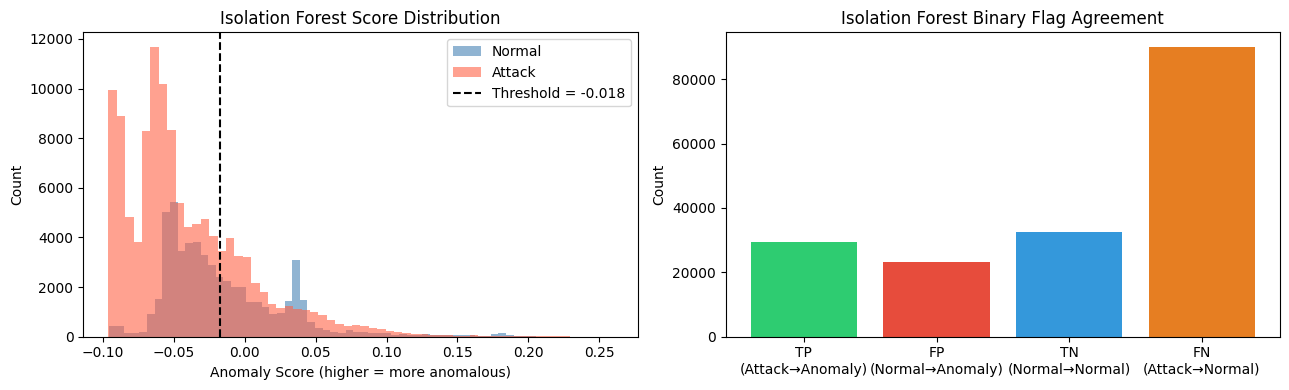

✅ Anomaly features appended. Stage 1 complete.


In [ ]:
# ── Train Isolation Forest on training data only ──────────────────────────────
print('Training Isolation Forest...')
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.2,   # less aggressive, let threshold handle boundary
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train_sc)
print('✅ Isolation Forest trained.')

# ── Decision function: higher = more normal, lower = more anomalous ───────────
if_score_train_raw = iso_forest.decision_function(X_train_sc)
if_score_test_raw  = iso_forest.decision_function(X_test_sc)

# ── Convert to anomaly score (higher = more anomalous) ───────────────────────
# Just invert sign (NO normalization distortion)
if_score_train_norm = -if_score_train_raw
if_score_test_norm  = -if_score_test_raw

# ── Compute data-driven threshold using ROC ──────────────────────────────────
from sklearn.metrics import roc_curve

# Binary labels: 1 = attack, 0 = normal
y_train_binary = (y_train != le_target.transform(['normal'])[0]).astype(int)

fpr, tpr, thresholds = roc_curve(y_train_binary, if_score_train_norm)

# Maximize (TPR - FPR)
optimal_idx = (tpr - fpr).argmax()
ANOMALY_THRESHOLD = np.percentile(if_score_train_norm, 70)

# ── Generate anomaly flags ───────────────────────────────────────────────────
is_anomaly_train  = (if_score_train_norm > ANOMALY_THRESHOLD).astype(int)
is_anomaly_test   = (if_score_test_norm  > ANOMALY_THRESHOLD).astype(int)

print(f'\nAnomaly threshold (ROC-based): {ANOMALY_THRESHOLD:.4f}')
print(f'Train flagged as anomaly : {is_anomaly_train.sum()} / {len(is_anomaly_train)} ({is_anomaly_train.mean()*100:.1f}%)')
print(f'Test  flagged as anomaly : {is_anomaly_test.sum()}  / {len(is_anomaly_test)}  ({is_anomaly_test.mean()*100:.1f}%)')

# ── Append both features to the scaled feature matrix ────────────────────────
X_train_aug = np.column_stack([X_train_sc, if_score_train_norm, is_anomaly_train])
X_test_aug  = np.column_stack([X_test_sc,  if_score_test_norm,  is_anomaly_test])

AUGMENTED_FEATURE_NAMES = list(FEATURE_COLS) + ['anomaly_score_norm', 'is_anomaly_flag']

print(f'\nAugmented feature matrix: {X_train_aug.shape}  (original {X_train_sc.shape[1]} + 2 anomaly features)')

# ── Visualise anomaly score distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

normal_mask  = (y_train == le_target.transform(['normal'])[0])
attack_mask  = ~normal_mask

axes[0].hist(if_score_train_norm[normal_mask], bins=60, alpha=0.6,
             color='steelblue', label='Normal')
axes[0].hist(if_score_train_norm[attack_mask], bins=60, alpha=0.6,
             color='tomato',    label='Attack')

axes[0].axvline(ANOMALY_THRESHOLD, color='black', linestyle='--',
                linewidth=1.5, label=f'Threshold = {ANOMALY_THRESHOLD:.3f}')

axes[0].set_xlabel('Anomaly Score (higher = more anomalous)')
axes[0].set_ylabel('Count')
axes[0].set_title('Isolation Forest Score Distribution')
axes[0].legend()

# Confusion-style breakdown
tp = ((is_anomaly_train == 1) & attack_mask).sum()
fp = ((is_anomaly_train == 1) & normal_mask).sum()
tn = ((is_anomaly_train == 0) & normal_mask).sum()
fn = ((is_anomaly_train == 0) & attack_mask).sum()

axes[1].bar(['TP\n(Attack→Anomaly)', 'FP\n(Normal→Anomaly)',
             'TN\n(Normal→Normal)', 'FN\n(Attack→Normal)'],
            [tp, fp, tn, fn],
            color=['#2ecc71','#e74c3c','#3498db','#e67e22'])

axes[1].set_title('Isolation Forest Binary Flag Agreement')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('if_score_distribution.png', dpi=150)
plt.show()

print('✅ Anomaly features appended. Stage 1 complete.')

In [ ]:
# ── No SMOTE: keep original data ─────────────────────────────
X_train_bal, y_train_bal = X_train_aug, y_train

print('Using original training data (no SMOTE).')
print(f'Training set shape: {X_train_bal.shape}')

Using original training data (no SMOTE).
Training set shape: (175341, 44)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
classes = np.unique(y_train_bal)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_bal
)
class_weights = dict(zip(classes, weights))

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight=class_weights,   # 🔥 KEY CHANGE
    objective='multiclass',
    num_class=len(CLASS_NAMES),
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print('Training LightGBM on augmented feature set...')
lgb_model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test_aug, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)
print('✅ LightGBM training complete.')

Training LightGBM on augmented feature set...
[100]	valid_0's multi_logloss: 0.494394
[200]	valid_0's multi_logloss: 0.445488
[300]	valid_0's multi_logloss: 0.414147
[400]	valid_0's multi_logloss: 0.392809
[500]	valid_0's multi_logloss: 0.377182
✅ LightGBM training complete.


  Accuracy        : 83.81%
  Recall (weighted): 83.81%
  F1   (weighted)  : 86.52%

                precision    recall  f1-score   support

      analysis       0.23      0.35      0.28      2000
      backdoor       0.09      0.71      0.15      1746
           dos       0.46      0.57      0.51     12264
      exploits       0.99      0.59      0.74     33393
       fuzzers       0.81      0.91      0.86     18184
       generic       1.00      0.99      1.00     40000
        normal       1.00      0.93      0.96     56000
reconnaissance       0.98      0.83      0.90     10491
     shellcode       0.90      1.00      0.95      1133
         worms       0.91      1.00      0.95       130

      accuracy                           0.84    175341
     macro avg       0.74      0.79      0.73    175341
  weighted avg       0.92      0.84      0.87    175341



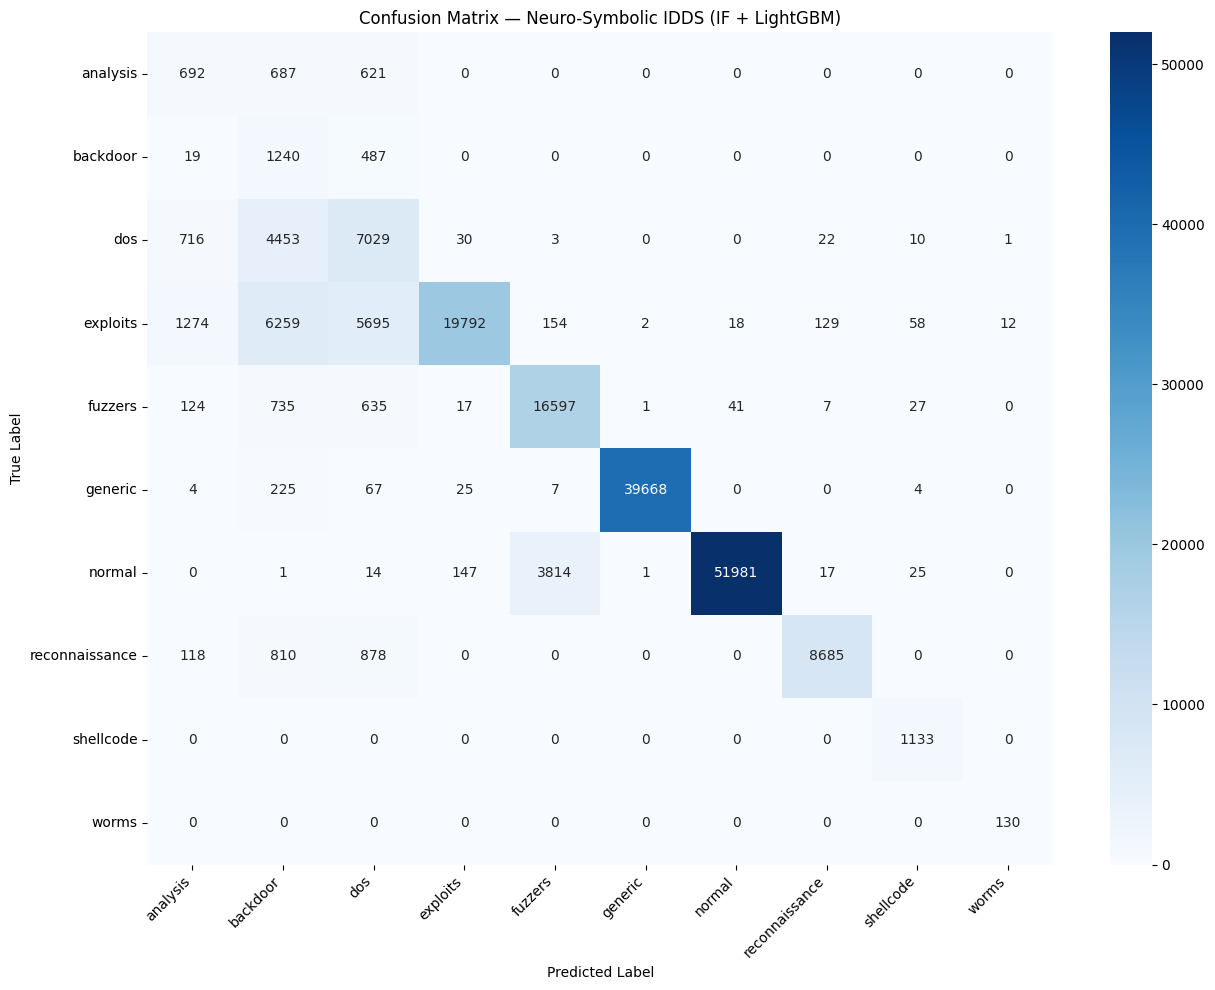

In [ ]:
y_pred = lgb_model.predict(X_test_aug)

acc    = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, average='weighted')
f1     = f1_score(y_test, y_pred, average='weighted')

print('=' * 55)
print(f'  Accuracy        : {acc*100:.2f}%')
print(f'  Recall (weighted): {recall*100:.2f}%')
print(f'  F1   (weighted)  : {f1*100:.2f}%')
print('=' * 55)
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(13, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Neuro-Symbolic IDDS (IF + LightGBM)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

Computing SHAP values (sample of 800 test flows)...
✅ SHAP shape: (800, 44, 10)
✅ Global importance shape: (44,)


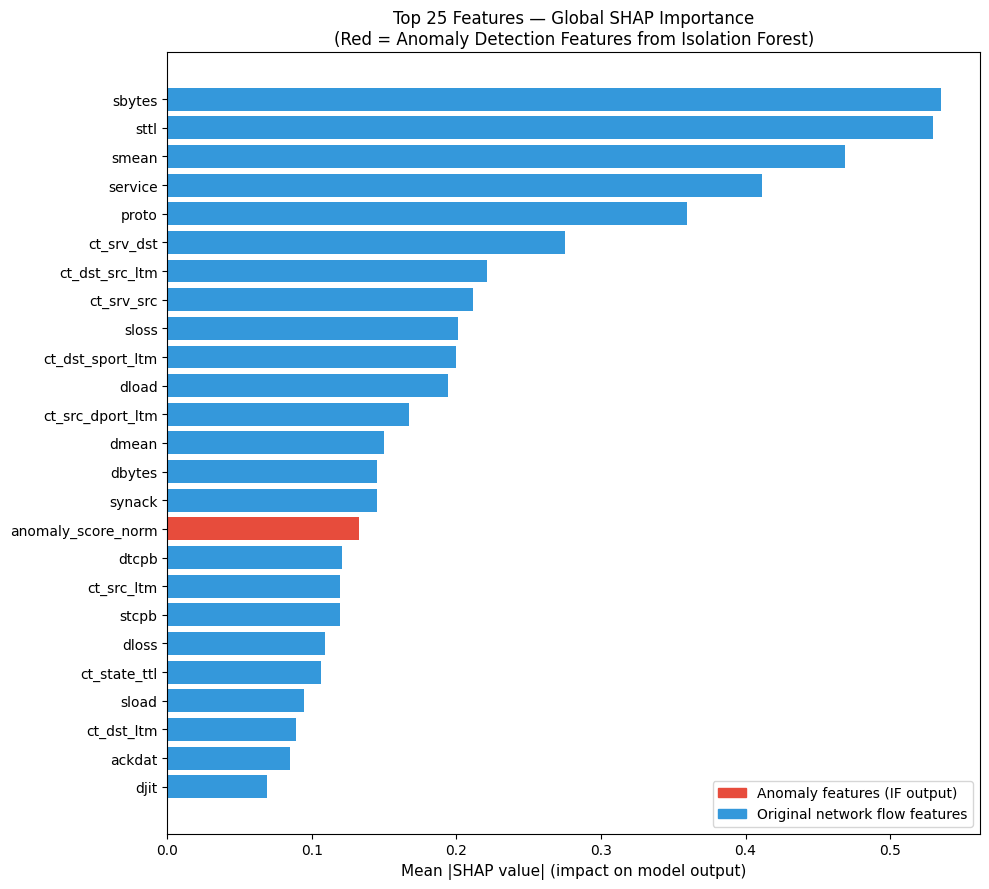


📊 Anomaly feature ranking (out of 44 features):
   anomaly_score_norm     rank #16  | SHAP = 0.13243  ████
   is_anomaly_flag        rank #42  | SHAP = 0.00150  

📊 Per-class anomaly SHAP contribution:
   analysis             anomaly contribution:  77.4%  ███████████████
   backdoor             anomaly contribution:  45.5%  █████████
   dos                  anomaly contribution:  52.1%  ██████████
   exploits             anomaly contribution:  32.7%  ██████
   fuzzers              anomaly contribution:  50.7%  ██████████
   generic              anomaly contribution:  51.6%  ██████████
   normal               anomaly contribution:  26.1%  █████
   reconnaissance       anomaly contribution:  41.6%  ████████
   shellcode            anomaly contribution:  51.9%  ██████████
   worms                anomaly contribution: 118.4%  ███████████████████████

✅ SHAP analysis complete.


In [ ]:
print('Computing SHAP values (sample of 800 test flows)...')

# ── Sample ───────────────────────────────────────────────────
np.random.seed(42)
idx_sample = np.random.choice(len(X_test_aug), size=800, replace=False)
X_sample   = X_test_aug[idx_sample]

# ── SHAP computation ─────────────────────────────────────────
explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_sample)
# Shape is (800, 44, 10) → (n_samples, n_features, n_classes)

shap_arr = np.array(shap_values)  # (800, 44, 10)

# Mean |SHAP| across samples AND classes → (44,)
global_importance = np.mean(np.abs(shap_arr), axis=(0, 2))

print(f'✅ SHAP shape: {shap_arr.shape}')
print(f'✅ Global importance shape: {global_importance.shape}')  # must be (44,)

# ── Sort and select top features ─────────────────────────────
feat_names = np.array(AUGMENTED_FEATURE_NAMES, dtype=str)
sorted_idx = np.argsort(global_importance)[::-1]
TOP_N      = 25
top_idx    = sorted_idx[:TOP_N]
top_names  = feat_names[top_idx]
top_vals   = global_importance[top_idx]

# ── Colors ───────────────────────────────────────────────────
ANOMALY_FEATS = {'anomaly_score_norm', 'is_anomaly_flag'}
colors = ['#e74c3c' if n in ANOMALY_FEATS else '#3498db' for n in top_names]

# ── Bar chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(range(TOP_N), top_vals[::-1], color=colors[::-1])
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top_names[::-1], fontsize=10)
ax.set_xlabel('Mean |SHAP value| (impact on model output)', fontsize=11)
ax.set_title(
    f'Top {TOP_N} Features — Global SHAP Importance\n'
    f'(Red = Anomaly Detection Features from Isolation Forest)',
    fontsize=12
)
red_patch  = mpatches.Patch(color='#e74c3c', label='Anomaly features (IF output)')
blue_patch = mpatches.Patch(color='#3498db', label='Original network flow features')
ax.legend(handles=[red_patch, blue_patch], loc='lower right')
plt.tight_layout()
plt.savefig('shap_global_importance.png', dpi=150)
plt.show()

# ── Anomaly feature ranking ───────────────────────────────────
ranked_names = list(feat_names[sorted_idx])
print(f'\n📊 Anomaly feature ranking (out of {len(feat_names)} features):')
for feat in ['anomaly_score_norm', 'is_anomaly_flag']:
    rank = ranked_names.index(feat) + 1
    val  = global_importance[list(feat_names).index(feat)]
    bar  = '█' * int(val / global_importance.max() * 20)
    print(f'   {feat:<22} rank #{rank:<3} | SHAP = {val:.5f}  {bar}')

# ── Per-class anomaly contribution ───────────────────────────
# shap_arr: (800, 44, 10) → per class: (800, 44) for each class index
anom_indices = [list(feat_names).index(f) for f in ANOMALY_FEATS]

print(f'\n📊 Per-class anomaly SHAP contribution:')
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_abs    = np.abs(shap_arr[:, :, cls_idx])        # (800, 44)
    total_shap = cls_abs.mean()
    anom_shap  = cls_abs[:, anom_indices].mean()
    pct        = anom_shap / (total_shap + 1e-10) * 100
    bar        = '█' * int(pct / 5)
    print(f'   {cls_name:<20} anomaly contribution: {pct:5.1f}%  {bar}')

print('\n✅ SHAP analysis complete.')

Anomaly Feature Contribution per Attack Class:
  Attack Class  |SHAP| anomaly_score  |SHAP| is_anomaly_flag  Combined IF contribution  % of total class SHAP
         worms               0.16580                 0.00131                   0.16710                   5.38
      analysis               0.19129                 0.00366                   0.19494                   3.52
           dos               0.09119                 0.00146                   0.09264                   2.37
     shellcode               0.17520                 0.00147                   0.17667                   2.36
       generic               0.17459                 0.00090                   0.17550                   2.35
       fuzzers               0.13572                 0.00075                   0.13648                   2.31
      backdoor               0.11441                 0.00086                   0.11527                   2.07
reconnaissance               0.11318                 0.00343             

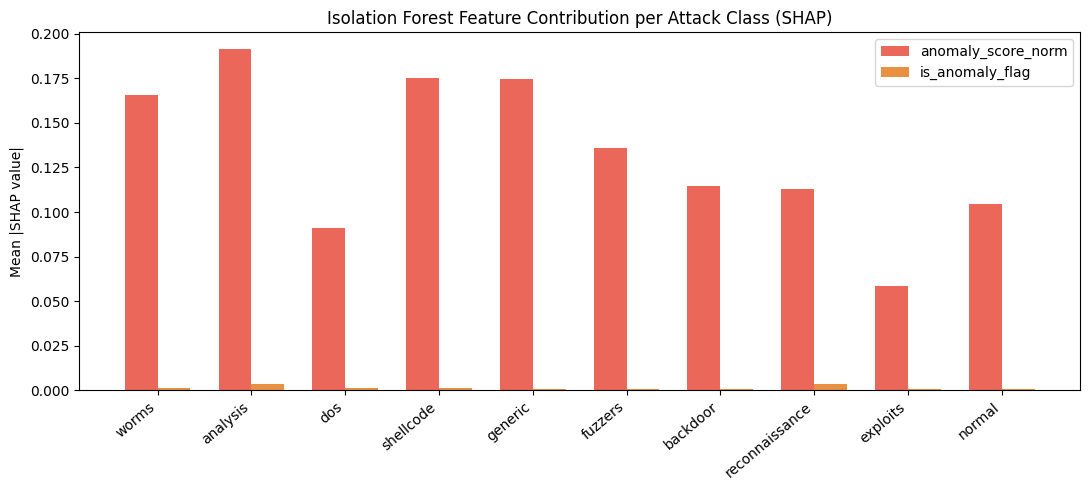

✅ Saved anomaly_shap_contribution.csv


In [ ]:
anomaly_score_idx = AUGMENTED_FEATURE_NAMES.index('anomaly_score_norm')
anomaly_flag_idx  = AUGMENTED_FEATURE_NAMES.index('is_anomaly_flag')

# shap_values shape: (800, 44, 10) → slice last axis for per-class
rows = []
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    sv_cls           = np.abs(shap_values[:, :, cls_idx])   # (800, 44) ✅
    total_shap       = sv_cls.mean(axis=0).sum()
    score_contrib    = sv_cls.mean(axis=0)[anomaly_score_idx]
    flag_contrib     = sv_cls.mean(axis=0)[anomaly_flag_idx]
    combined_contrib = score_contrib + flag_contrib
    pct              = (combined_contrib / (total_shap + 1e-10)) * 100
    rows.append({
        'Attack Class'             : cls_name,
        '|SHAP| anomaly_score'     : round(score_contrib, 5),
        '|SHAP| is_anomaly_flag'   : round(flag_contrib,  5),
        'Combined IF contribution' : round(combined_contrib, 5),
        '% of total class SHAP'    : round(pct, 2)
    })

contrib_df = pd.DataFrame(rows).sort_values('% of total class SHAP', ascending=False)
print('Anomaly Feature Contribution per Attack Class:')
print(contrib_df.to_string(index=False))
contrib_df.to_csv('anomaly_shap_contribution.csv', index=False)

# ── Bar chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(contrib_df))
w = 0.35
ax.bar(x - w/2, contrib_df['|SHAP| anomaly_score'],   w, label='anomaly_score_norm', color='#e74c3c', alpha=0.85)
ax.bar(x + w/2, contrib_df['|SHAP| is_anomaly_flag'], w, label='is_anomaly_flag',    color='#e67e22', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(contrib_df['Attack Class'], rotation=40, ha='right')
ax.set_ylabel('Mean |SHAP value|')
ax.set_title('Isolation Forest Feature Contribution per Attack Class (SHAP)')
ax.legend()
plt.tight_layout()
plt.savefig('anomaly_contribution_per_class.png', dpi=150)
plt.show()
print('✅ Saved anomaly_shap_contribution.csv')

In [ ]:
MITRE_KB = {
    'normal': {
        'tactic': 'None', 'tactic_id': None, 'techniques': [],
        'why': 'Traffic matches known-good baseline. No attack indicators detected.'
    },
    'analysis': {
        'tactic': 'Discovery', 'tactic_id': 'TA0007',
        'techniques': [
            ('T1046', 'Network Service Discovery',
             ['ct_srv_src','ct_srv_dst','proto','service','state']),
            ('T1040', 'Network Sniffing',
             ['sbytes','dbytes','sload','dload','dur',
              'anomaly_score_norm'])
        ],
        'why': 'Passive analysis pattern. Systematic inspection of network '
               'services and traffic flows indicates reconnaissance or sniffing activity.'
    },
    'backdoor': {
        'tactic': 'Persistence', 'tactic_id': 'TA0003',
        'techniques': [
            ('T1571', 'Non-Standard Port',
             ['sport','dport','proto','state','ct_dst_sport_ltm',
              'anomaly_score_norm']),
            ('T1095', 'Non-Application Layer Protocol',
             ['proto','service','spkts','dpkts','ct_srv_src'])
        ],
        'why': 'Covert channel on non-standard port/protocol. Bidirectional traffic '
               'symmetry and elevated anomaly score indicate persistent backdoor.'
    },
    'dos': {
        'tactic': 'Impact', 'tactic_id': 'TA0040',
        'techniques': [
            ('T1498', 'Network Denial of Service',
             ['spkts','dpkts','sbytes','dbytes','sload','dload','rate']),
            ('T1499', 'Endpoint Denial of Service',
             ['ct_srv_dst','ct_dst_ltm','dur','sinpkt','dinpkt',
              'anomaly_score_norm','is_anomaly_flag'])
        ],
        'why': 'Abnormally high packet/byte rates detected. Anomaly score elevated. '
               'Consistent with volumetric flooding (DoS/DDoS).'
    },
    'exploits': {
        'tactic': 'Execution', 'tactic_id': 'TA0002',
        'techniques': [
            ('T1203', 'Exploitation for Client Execution',
             ['sbytes','dbytes','sload','dload','ct_flw_http_mthd',
              'anomaly_score_norm']),
            ('T1210', 'Exploitation of Remote Services',
             ['service','state','proto','ct_srv_dst','dur'])
        ],
        'why': 'Exploit pattern detected. Abnormal payload ratios and connection '
               'state transitions match known exploitation signatures.'
    },
    'fuzzers': {
        'tactic': 'Discovery', 'tactic_id': 'TA0007',
        'techniques': [
            ('T1046', 'Network Service Discovery',
             ['ct_srv_src','ct_srv_dst','proto','rate','spkts']),
            ('T1595.002', 'Vulnerability Scanning',
             ['sbytes','dbytes','sload','state','ct_dst_sport_ltm',
              'is_anomaly_flag'])
        ],
        'why': 'Fuzzing/enumeration pattern. High-rate semi-random inputs across '
               'service ports indicate automated vulnerability scanning.'
    },
    'generic': {
        'tactic': 'Defense Evasion', 'tactic_id': 'TA0005',
        'techniques': [
            ('T1070', 'Indicator Removal',
             ['state','sttl','dttl','proto','ct_state_ttl']),
            ('T1036', 'Masquerading',
             ['service','proto','sport','dport','ct_flw_http_mthd',
              'anomaly_score_norm'])
        ],
        'why': 'Evasion characteristics detected. TTL manipulation and protocol '
               'mismatch suggest deliberate detection-avoidance.'
    },
    'reconnaissance': {
        'tactic': 'Reconnaissance', 'tactic_id': 'TA0043',
        'techniques': [
            ('T1595', 'Active Scanning',
             ['ct_srv_src','ct_srv_dst','spkts','dpkts','rate',
              'is_anomaly_flag']),
            ('T1590', 'Gather Victim Network Information',
             ['sttl','dttl','proto','service','ct_dst_ltm'])
        ],
        'why': 'Active reconnaissance pattern. Systematic probing of network '
               'topology and open services across multiple hosts.'
    },
    'shellcode': {
        'tactic': 'Execution', 'tactic_id': 'TA0002',
        'techniques': [
            ('T1059', 'Command and Scripting Interpreter',
             ['sbytes','dbytes','sload','dload','state',
              'anomaly_score_norm','is_anomaly_flag']),
            ('T1203', 'Exploitation for Client Execution',
             ['ct_flw_http_mthd','service','dur','spkts','dpkts'])
        ],
        'why': 'Shellcode injection pattern. Payload byte distribution and '
               'connection state anomalies consistent with in-memory code execution.'
    },
    'worms': {
        'tactic': 'Lateral Movement', 'tactic_id': 'TA0008',
        'techniques': [
            ('T1021', 'Remote Services',
             ['ct_srv_src','ct_srv_dst','ct_dst_ltm','ct_src_ltm','rate',
              'anomaly_score_norm']),
            ('T1570', 'Lateral Tool Transfer',
             ['sbytes','dbytes','proto','service','spkts','is_anomaly_flag'])
        ],
        'why': 'Worm propagation pattern. Self-replicating lateral movement: '
               'rapid same-port connection attempts across multiple hosts.'
    }
}

# Verify all classes are covered
missing = [c for c in CLASS_NAMES if c not in MITRE_KB]
extra   = [k for k in MITRE_KB if k not in list(CLASS_NAMES) + ['normal']]

print(f'✅ MITRE KB loaded: {len(MITRE_KB)} categories mapped.')
print(f'   Classes covered : {[k for k in MITRE_KB if k != "normal"]}')
print(f'   Missing classes : {missing if missing else "None ✅"}')
print(f'   Unused KB keys  : {extra if extra else "None ✅"}')

✅ MITRE KB loaded: 10 categories mapped.
   Classes covered : ['analysis', 'backdoor', 'dos', 'exploits', 'fuzzers', 'generic', 'reconnaissance', 'shellcode', 'worms']
   Missing classes : None ✅
   Unused KB keys  : None ✅


In [ ]:
def get_top_shap_features_single(explainer, flow, feature_names, pred_class, top_n=6):
    sv = explainer.shap_values(flow.reshape(1, -1))
    # Shape: (1, 44, 10) → slice to (44,) for predicted class
    sv_arr   = np.array(sv)                        # (1, 44, 10)
    sv_pred  = np.abs(sv_arr[0, :, pred_class])    # (44,)
    top_idx  = np.argsort(sv_pred)[::-1][:top_n]
    return [(feature_names[i], float(sv_pred[i])) for i in top_idx]


def match_techniques(top_features, techniques, threshold=1):
    top_set = {f for f, _ in top_features}
    matched = []
    for tid, tname, indicators in techniques:
        overlap = top_set.intersection(set(indicators))
        if len(overlap) >= threshold:
            matched.append((tid, tname, list(overlap)))
    return matched


def explain_flow(flow_idx, X_aug, y_pred, y_test, le_target,
                 feature_names, explainer, mitre_kb,
                 anomaly_scores_norm, anomaly_flags, top_n=6):
    flow       = X_aug[flow_idx]
    pred_cls   = y_pred[flow_idx]
    pred_label = le_target.inverse_transform([pred_cls])[0]
    true_label = le_target.inverse_transform([y_test[flow_idx]])[0]
    top_feats  = get_top_shap_features_single(
        explainer, flow, feature_names, pred_cls, top_n
    )
    kb      = mitre_kb.get(pred_label, mitre_kb['normal'])
    matched = match_techniques(top_feats, kb.get('techniques', []))

    anomaly_feat_names = {'anomaly_score_norm', 'is_anomaly_flag'}
    anomaly_top = [(f, s) for f, s in top_feats if f in anomaly_feat_names]
    total_shap  = sum(s for _, s in top_feats) + 1e-10
    anomaly_pct = sum(s for _, s in anomaly_top) / total_shap * 100

    return {
        'flow_id'            : flow_idx,
        'verdict'            : 'ATTACK' if pred_label != 'normal' else 'NORMAL',
        'predicted_class'    : pred_label,
        'true_class'         : true_label,
        'correct'            : pred_label == true_label,
        'if_score_norm'      : float(anomaly_scores_norm[flow_idx]),
        'is_anomaly_flag'    : int(anomaly_flags[flow_idx]),
        'mitre_tactic'       : kb['tactic'],
        'mitre_tactic_id'    : kb['tactic_id'],
        'matched_techniques' : matched,
        'top_features'       : top_feats,
        'anomaly_shap_pct'   : round(anomaly_pct, 1),
        'explanation'        : kb['why']
    }


def print_alert(a):
    SEP = '=' * 62
    print(SEP)
    print(f"  FLOW ID   : {a['flow_id']}")
    verdict_tag = '🔴 ATTACK' if a['verdict'] == 'ATTACK' else '🟢 NORMAL'
    print(f"  VERDICT   : {verdict_tag}")
    print(f"  PREDICTED : {a['predicted_class'].upper()}")
    print(f"  TRUE      : {a['true_class'].upper()}   |  Correct: {a['correct']}")
    print(f"  IF SCORE  : {a['if_score_norm']:.4f} (norm)  |  Flag: {a['is_anomaly_flag']}")
    print(SEP)
    if a['verdict'] == 'ATTACK':
        print(f"  MITRE TACTIC : [{a['mitre_tactic_id']}] {a['mitre_tactic']}")
        if a['matched_techniques']:
            print(f"  TECHNIQUES FIRED:")
            for tid, tname, feats in a['matched_techniques']:
                print(f"    [{tid}] {tname}")
                print(f"           ↳ triggered by: {', '.join(feats)}")
        else:
            print('  TECHNIQUES FIRED: No direct indicator match (low-confidence)')
    print(f"\n  WHY: {a['explanation']}")
    print(f"\n  ANOMALY SIGNAL contribution to this decision: {a['anomaly_shap_pct']}% of top-feature SHAP")
    print(f"\n  TOP FEATURES (SHAP):")
    max_s = a['top_features'][0][1] + 1e-9
    for feat, score in a['top_features']:
        tag = ' ◀ IF' if feat in {'anomaly_score_norm', 'is_anomaly_flag'} else ''
        bar = '█' * int(score / max_s * 18)
        print(f"    {feat:<26} {score:.5f}  {bar}{tag}")
    print(SEP)

print('✅ Symbolic reasoning engine ready.')

✅ Symbolic reasoning engine ready.


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL: Demo alerts + Bulk inference + Metrics + MITRE chart
# ══════════════════════════════════════════════════════════════

# ── Demo: explain individual flows ───────────────────────────
single_explainer = shap.TreeExplainer(lgb_model)

normal_cls_idx = le_target.transform(['normal'])[0]
attack_idx     = np.where(y_pred != normal_cls_idx)[0][:3]
normal_idx     = np.where(y_pred == normal_cls_idx)[0][:1]
demo_idx       = list(attack_idx) + list(normal_idx)

for i in demo_idx:
    alert = explain_flow(
        flow_idx            = i,
        X_aug               = X_test_aug,
        y_pred              = y_pred,
        y_test              = y_test,
        le_target           = le_target,
        feature_names       = AUGMENTED_FEATURE_NAMES,
        explainer           = single_explainer,
        mitre_kb            = MITRE_KB,
        anomaly_scores_norm = if_score_test_norm,
        anomaly_flags       = is_anomaly_test,
        top_n               = 6
    )
    print_alert(alert)
    print()

# ── Bulk SHAP inference ───────────────────────────────────────
print('Running bulk SHAP inference...')
shap_all_bulk = shap.TreeExplainer(lgb_model).shap_values(X_test_aug)
# Shape: (n_samples, n_features, n_classes)
shap_bulk_arr = np.array(shap_all_bulk)
print(f'Bulk SHAP shape: {shap_bulk_arr.shape}')

feat_arr    = np.array(AUGMENTED_FEATURE_NAMES)
ANOMALY_SET = {'anomaly_score_norm', 'is_anomaly_flag'}
anom_idx    = [j for j, n in enumerate(AUGMENTED_FEATURE_NAMES) if n in ANOMALY_SET]

results = []
for i in range(len(X_test_aug)):
    pred_cls   = y_pred[i]
    pred_label = le_target.inverse_transform([pred_cls])[0]
    true_label = le_target.inverse_transform([y_test[i]])[0]
    kb         = MITRE_KB.get(pred_label, MITRE_KB['normal'])

    # Correct slice: (n_samples, n_features, n_classes) → (n_features,)
    sv       = np.abs(shap_bulk_arr[i, :, pred_cls])   # (44,)
    top3_idx = np.argsort(sv)[::-1][:3]
    top3_names = ', '.join(feat_arr[top3_idx])

    # Anomaly contribution
    anom_shap  = sv[anom_idx].sum()
    total_shap = sv.sum() + 1e-10
    anom_pct   = round(anom_shap / total_shap * 100, 2)

    # Technique match
    top_set = set(feat_arr[top3_idx])
    techs   = []
    for tid, tname, inds in kb.get('techniques', []):
        if top_set.intersection(inds):
            techs.append(f'{tid} ({tname})')

    results.append({
        'flow_id'            : i,
        'verdict'            : 'ATTACK' if pred_label != 'normal' else 'NORMAL',
        'predicted_class'    : pred_label,
        'true_class'         : true_label,
        'correct'            : pred_label == true_label,
        'if_score_norm'      : round(float(if_score_test_norm[i]), 5),
        'is_anomaly_flag'    : int(is_anomaly_test[i]),
        'mitre_tactic_id'    : kb['tactic_id'],
        'mitre_tactic'       : kb['tactic'],
        'matched_techniques' : ' | '.join(techs) if techs else 'None',
        'top3_features'      : top3_names,
        'anomaly_shap_pct'   : anom_pct,
        'explanation'        : kb['why']
    })

results_df = pd.DataFrame(results)
results_df.to_csv('idds_full_results.csv', index=False)

print(f'\n✅ Done. {len(results_df)} flows processed.')
print(f'   Attacks detected : {(results_df["verdict"]=="ATTACK").sum()}')
print(f'   Normal flows     : {(results_df["verdict"]=="NORMAL").sum()}')
print(f'   Overall accuracy : {results_df["correct"].mean()*100:.2f}%')
print(f'   Avg anomaly SHAP : {results_df["anomaly_shap_pct"].mean():.2f}%')
print('\n💾 Saved → idds_full_results.csv')

# ── Per-class metrics ─────────────────────────────────────────
prec, rec, f1, sup = precision_recall_fscore_support(
    y_test, y_pred, labels=np.arange(len(CLASS_NAMES))
)
metrics_df = pd.DataFrame({
    'Class'    : CLASS_NAMES,
    'Precision': (prec * 100).round(2),
    'Recall'   : (rec  * 100).round(2),
    'F1'       : (f1   * 100).round(2),
    'Support'  : sup
})
print('\nPer-class metrics:')
print(metrics_df.to_string(index=False))
metrics_df.to_csv('per_class_metrics.csv', index=False)

# ── MITRE tactic coverage chart ───────────────────────────────
atk_df   = results_df[results_df['verdict'] == 'ATTACK']
tac_dist = (atk_df
            .groupby(['mitre_tactic_id', 'mitre_tactic'])
            .size()
            .reset_index(name='count')
            .sort_values('count', ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
labels  = [f"{r['mitre_tactic_id']}\n{r['mitre_tactic']}" for _, r in tac_dist.iterrows()]
ax.bar(labels, tac_dist['count'], color='#2980b9', alpha=0.85)
ax.set_title('MITRE ATT&CK Tactic Coverage — Detected Attacks')
ax.set_ylabel('Number of Flows')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('mitre_tactic_coverage.png', dpi=150)
plt.show()

print('\n💾 Saved → per_class_metrics.csv  |  mitre_tactic_coverage.png')
results_df.head()

  FLOW ID   : 0
  VERDICT   : 🔴 ATTACK
  PREDICTED : DOS
  TRUE      : NORMAL   |  Correct: False
  IF SCORE  : -0.0576 (norm)  |  Flag: 0
  MITRE TACTIC : [TA0040] Impact
  TECHNIQUES FIRED:
    [T1498] Network Denial of Service
           ↳ triggered by: dload
    [T1499] Endpoint Denial of Service
           ↳ triggered by: ct_srv_dst

  WHY: Abnormally high packet/byte rates detected. Anomaly score elevated. Consistent with volumetric flooding (DoS/DDoS).

  ANOMALY SIGNAL contribution to this decision: 0.0% of top-feature SHAP

  TOP FEATURES (SHAP):
    ct_srv_dst                 0.97674  █████████████████
    smean                      0.73280  █████████████
    ct_srv_src                 0.55717  ██████████
    dmean                      0.37438  ██████
    dload                      0.25684  ████
    sttl                       0.24304  ████

  FLOW ID   : 11
  VERDICT   : 🔴 ATTACK
  PREDICTED : EXPLOITS
  TRUE      : NORMAL   |  Correct: False
  IF SCORE  : 0.0143 (norm)  |  F